In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "D:/share/fonts/nanum-all_new/나눔 글꼴/나눔고딕/NanumFontSetup_TTF_GOTHIC/NanumGothic.ttf"  
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
import IPython.display
import pickle
BRIGHT_BLACK = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
BRIGHT_WHITE = '\033[97m'
BRIGHT_END = '\033[0m'

import missingno as msno
import folium
from folium.plugins import HeatMap

plt.rcParams['font.family'] = 'NanumBarunGothic'  
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'Arial', 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


In [3]:
weather = pd.read_csv('data/final_weather.csv')
weather = weather.drop(columns=['Unnamed: 0'])
display(weather.head(2))
df = pd.read_csv('data/data_checkpoint2.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df.head(2)

,datetime,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort
0,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0
1,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0


,대여소번호,운동량,이용건수,이용시간(분),탄소량,이동거리(M),type,gender,age,datetime,hour
0,1725,0.00,1,44,0.00,0.0,regular,U,10s,2022-01-01,0
1,1167,52.51,1,15,0.51,2210.0,regular,U,10s,2022-01-01,0


In [4]:
rcg = df.groupby(['datetime','type']).agg({'이용건수': 'sum'}).reset_index()
rcg_pivot = rcg.pivot(index='datetime', columns='type', values='이용건수').fillna(0).reset_index()

weather['datetime'] = pd.to_datetime(weather['datetime'])
pd.merge(rcg_pivot, weather).sort_values(by = 'datetime').to_csv('data/datetime_rcg_weather.csv', index = False)
datetime_rcg_weather = pd.read_csv('data/datetime_rcg_weather.csv')

parsed = datetime_rcg_weather['datetime'].apply(lambda x : pd.to_datetime(x))
datetime_rcg_weather['year'] = parsed.apply(lambda x : x.year)
datetime_rcg_weather['month'] = parsed.apply(lambda x : x.month)
datetime_rcg_weather['day'] = parsed.apply(lambda x : x.day)
datetime_rcg_weather['hour'] = parsed.apply(lambda x : x.hour)
datetime_rcg_weather['dayofweek'] = parsed.apply(lambda x : x.dayofweek)
datetime_rcg_weather.head() # 7.html

,datetime,casual,group,regular,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort,year,month,day,hour,dayofweek
0,2022-01-01 00:00:00,145.0,12.0,418.0,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0,2022,1,1,0,5
1,2022-01-01 01:00:00,117.0,1.0,348.0,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0,2022,1,1,1,5
2,2022-01-01 02:00:00,57.0,1.0,270.0,-11.0,-17.0,62.0,2.0,25.0,9.0,0,-15.645662,0,2022,1,1,2,5
3,2022-01-01 03:00:00,63.0,1.0,186.0,-12.0,-18.0,61.0,2.0,27.0,9.0,0,-16.718002,0,2022,1,1,3,5
4,2022-01-01 04:00:00,68.0,8.0,170.0,-13.0,-17.0,72.0,4.0,20.0,7.0,0,-17.645662,0,2022,1,1,4,5


In [5]:
with open('data/강서구_시간대여소별_대여이력정보.pickle', 'rb') as f: # model.ipynb에서 만든 파일
    data1 = pickle.load(f)
    
# 모든 대여소를 하나의 long-form DataFrame으로
eda_df_list = []
for sid, df_ in data1.items():
    tmp = df_.copy()
    tmp['station_id'] = sid
    tmp['datetime']   = pd.to_datetime(tmp['시간대'])
    eda_df_list.append(tmp)

eda = pd.concat(eda_df_list, ignore_index=True)

# weather 붙이기 (이미 wth 만들었으므로 index 맞추기)
wth_idx = weather.copy()
wth_idx['datetime'] = pd.date_range('2022-01-01 00:00', periods=len(weather), freq='H')
eda = eda.merge(wth_idx, on='datetime', how='left')

# 빠른 스냅샷
print(eda.shape)
display(eda.head())

(832200, 19)


,시간대,대여,대여_이용거리,대여_이용시간,반납,반납_이용거리,반납_이용시간,반납-대여,station_id,datetime,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort
0,2022-01-01 00,0,0.0,0,0,0.0,0,0,1101,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0
1,2022-01-01 01,0,0.0,0,0,0.0,0,0,1101,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0
2,2022-01-01 02,0,0.0,0,0,0.0,0,0,1101,2022-01-01 02:00:00,-11.0,-17.0,62.0,2.0,25.0,9.0,0,-15.645662,0
3,2022-01-01 03,0,0.0,0,1,0.0,3,1,1101,2022-01-01 03:00:00,-12.0,-18.0,61.0,2.0,27.0,9.0,0,-16.718002,0
4,2022-01-01 04,0,0.0,0,0,0.0,0,0,1101,2022-01-01 04:00:00,-13.0,-17.0,72.0,4.0,20.0,7.0,0,-17.645662,0


# 관찰

## windforce

Text(0.5, 1.0, 'Distribution of Wind Force')

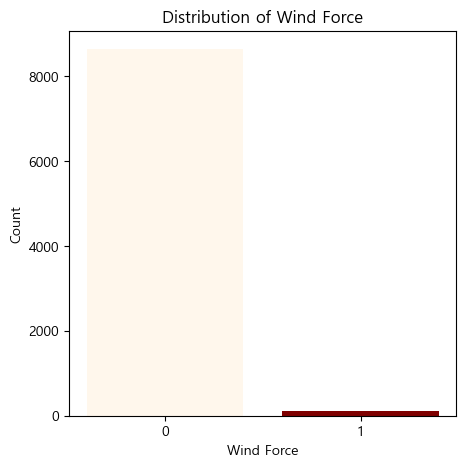

In [35]:
windforce_counts = datetime_rcg_weather['windforce'].value_counts().sort_index()
plt.figure(figsize = (5,5))
cmap = plt.cm.OrRd
# cmap = plt.cm.Blues
n = len(windforce_counts)
colors = [cmap(i / (n - 1)) for i in range(n)]
bars = plt.bar(windforce_counts.index.astype(str), 
               windforce_counts.values,
               color=colors)
plt.xlabel('Wind Force')
plt.ylabel('Count')
plt.title('Distribution of Wind Force')

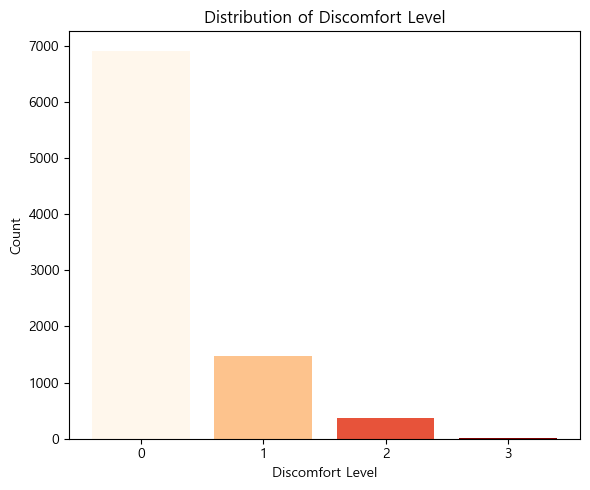

In [36]:
# 불쾌지수 value_counts를 미리 정리
discomfort_counts = datetime_rcg_weather['discomfort'].value_counts().sort_index()
colors = colors[:len(discomfort_counts)]  
plt.figure(figsize=(6, 5))
n = len(discomfort_counts)
colors = [cmap(i / (n - 1)) for i in range(n)]
bars = plt.bar(discomfort_counts.index.astype(str), 
               discomfort_counts.values,
               color=colors)

plt.xlabel('Discomfort Level')
plt.ylabel('Count')
plt.title('Distribution of Discomfort Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## month & type

- 1~2월 (겨울): 이용량 최저점
- 5월 & 9월: 최고점 → 봄과 가을
- 7~8월: 감소 (더운 여름)   
=> hour& type 를 같이 고려했을 때, 정기 사용자는 출퇴근, 생활 교통 수단으로 이용   
=> 추운 겨울 & 더운 여름엔 사용량 감소 → 날씨 영향 명확   
=> 쾌적한 봄/가을(5월, 9월)에 가장 많이 사용   

- month는 type별로 다 유사한 패턴을 보임

<Axes: xlabel='month', ylabel='regular'>

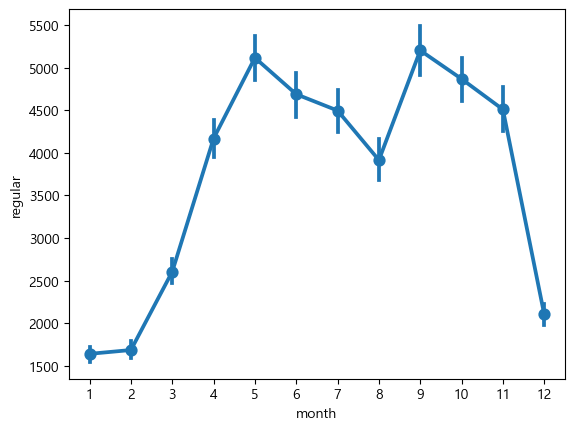

In [37]:
sns.pointplot(data = datetime_rcg_weather, x = 'month', y = 'regular')
# 겨울에 이용량이 적고, 엄청 더울 때에도 이용량이 감소한다.

<Axes: xlabel='month', ylabel='casual'>

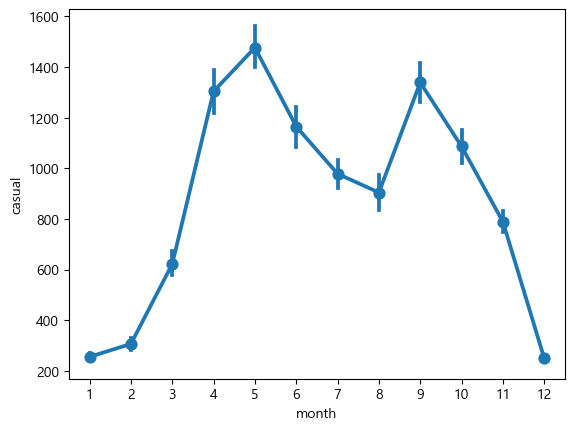

In [40]:
sns.pointplot(data = datetime_rcg_weather, x = 'month', y = 'casual')

<Axes: xlabel='month', ylabel='group'>

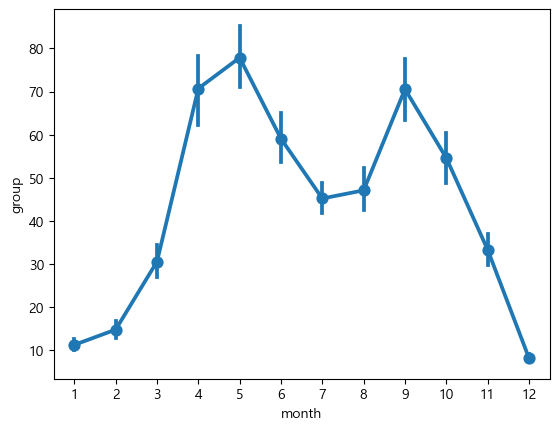

In [41]:
sns.pointplot(data = datetime_rcg_weather, x = 'month', y = 'group')

## 시간대별 평균 수요 확인

,시간대,대여,대여_이용거리,대여_이용시간,반납,반납_이용거리,반납_이용시간,반납-대여,station_id,datetime,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort,hour
0,2022-01-01 00,0,0.0,0,0,0.0,0,0,1101,2022-01-01 00:00:00,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0,0
1,2022-01-01 01,0,0.0,0,0,0.0,0,0,1101,2022-01-01 01:00:00,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0,1


,hour,대여,반납,반납-대여
0,0,1.482278,0.925278,-0.557001
1,1,0.893929,0.548378,-0.345552


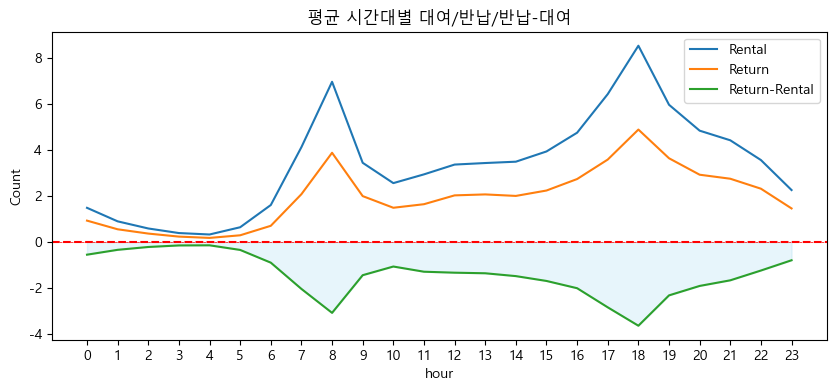

In [ ]:
# 시간(hour)에 따라 따릉이 대여/반납/공급-수요 차이의 평균 변화 시각화
# 하루 24시간 동안의 수요-공급 패턴을 분석
eda['hour'] = eda['datetime'].dt.hour
display(eda.head(2))
hourly = eda.groupby('hour')[['대여','반납','반납-대여']].mean().reset_index()
display(hourly.head(2))
# 대여 : 시간대별 평균 대여량
# 반납 : 시간대별 평균 반납량
# 반납-대여 : 시간대별 평균 반납량 - 대여량. 자전거 부족 및 잉여 시간대 확인

plt.figure(figsize=(10,4))
sns.lineplot(x='hour', y='대여', data=hourly, label='Rental')
sns.lineplot(x='hour', y='반납', data=hourly, label='Return')
sns.lineplot(x='hour', y='반납-대여', data=hourly, label='Return-Rental')  
plt.axhline(0, color='red', linestyle='--', linewidth=0.5)  # y=0 기준선
plt.title('평균 시간대별 대여/반납/반납-대여')
plt.xticks(range(0,24))
plt.ylabel('Count')
plt.axhline(0, color='red', ls='--')
plt.fill_between(hourly['hour'], 0, hourly['반납-대여'], where=hourly['반납-대여'] < 0, color='skyblue', alpha=0.2, label='수요 > 공급')
plt.fill_between(hourly['hour'], 0, hourly['반납-대여'], where=hourly['반납-대여'] > 0, color='orange', alpha=0.2, label='공급 > 수요')
plt.show()

| 시간대         |  관찰                                              | 의미                              | 해석                 |
| ----------- | ------------------------------------------------ | --------------------------------- | ---------------------- |
| **0\~5시**   | 대여, 반납 모두 낮음                 | 새벽시간, 이용 거의 없음                    | 운영 종료 시간 또는 재배치 시간대 적합 |
| **6\~9시**   | 대여 급증 (출근), 반납은 상대적으로 낮음<br>→ `반납-대여` 음수 | **출근 시간** 대여 수요 폭발<br>→ 자전거 부족 발생 | 🔺공급 필요: 자전거 미리 채워야 함  |
| **10\~16시** | 대여·반납 균형 (완만)                                    | 낮 시간대 비교적 안정적 흐름                  | 운영 유지, 모니터링 수준         |
| **17\~19시** | 대여량 또 한 번 급증 → 반납-대여 최저점    | **퇴근 시간** → 자전거 부족 심화       | 🔺공급 필요: 자전거 미리 채워야 함. 대여 피크가 퇴근 시간대(18시)에 다시 한번 발생  |
| **20\~23시** | 대여량 감소, 반납량도 감소                                  | 저녁 이후 여유 시간                       |재배치 시간대 적합         |


<Axes: >

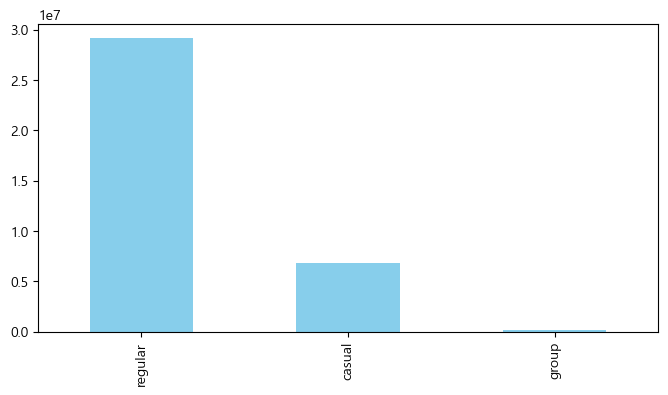

In [51]:
df['type'].value_counts().plot(kind='bar', figsize=(8, 4), color='skyblue')
# regular가 압도적으로 많아서 위 그래프는 regular사용자들의 그래프 모양을 가지고 있을 가능성이 높음

## hour & type

- regular 이용자 (정기 이용자)
- 특징적인 두 개의 뾰족한 피크가 보임:

    - 07~09시: 출근 시간 피크

    - 17~19시: 퇴근 시간 피크

- 낮 시간대(10~16시)는 상대적으로 평이함

➡️ 출퇴근 목적의 통근용 정기 사용자 중심    
→ regular 사용자들은 자전거를 실질적인 교통수단으로 활용함

<Axes: xlabel='hour', ylabel='regular'>

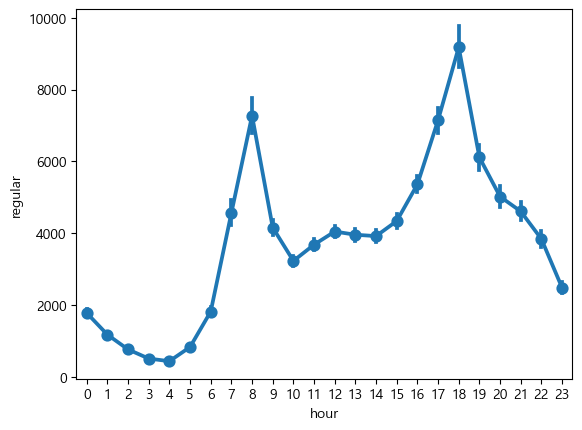

In [47]:
sns.pointplot(data = datetime_rcg_weather, x = 'hour', y = 'regular')
# 위 그래프는 압도적으로 양이 많은 regular 대여량의 그래프 형태를 따라가는걸 확인할 수 있음

- casual 이용자 (일회성/비정기 이용자)
- 출근 피크 없음. 대신
    - 오전 10시부터 오후 18시까지 꾸준히 증가

    - 18시쯤 최고점 찍고 이후 감소

- 새벽·야간엔 이용 거의 없음

➡️ 관광·산책·가벼운 외출 목적   
→ 출퇴근과 무관한 여가·일상용 이용자가 중심

<Axes: xlabel='hour', ylabel='casual'>

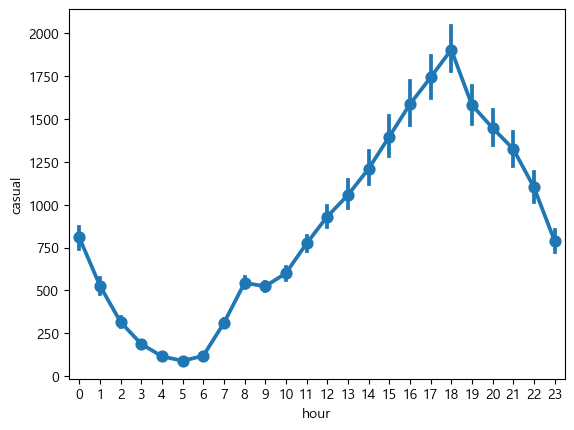

In [48]:
sns.pointplot(data = datetime_rcg_weather, x = 'hour', y = 'casual')

- group 이용 (아마 단체 대여 or 다수 인원 대여)
- 오전엔 거의 없음
- 오후 14~18시 사이 집중
- 에러바가 상대적으로 큼 → 데이터 수가 적고 변동성이 큼   
➡️ 관광/야외활동에 참여한 단체가 주로 오후에 몰림   
→ 예: 기업 워크숍, 대학 동아리, 가족 단위 등

<Axes: xlabel='hour', ylabel='group'>

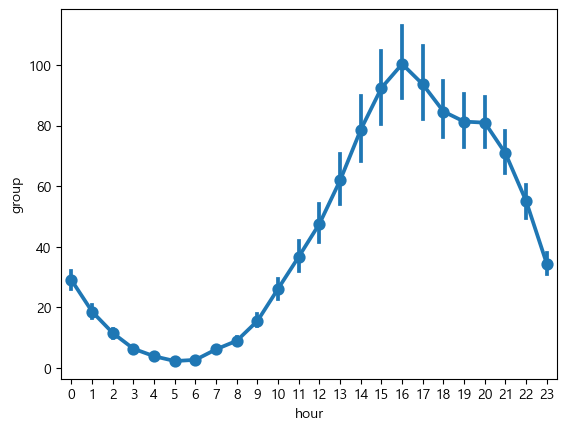

In [49]:
sns.pointplot(data = datetime_rcg_weather, x = 'hour', y = 'group')

| 구분        | 패턴                     | 해석                 | 전략적 시사점                   |
| --------- | ---------------------- | ------------------ | ------------------------- |
| `regular` | 출퇴근 시간 뚜렷한 피크          | 출근/퇴근 교통수단         | **출퇴근 시간 자전거 공급 보장** 필요   |
| `casual`  | 오전\~오후 천천히 증가 후 저녁에 하락 | 여가/가벼운 외출 중심       | **관광지·공원 근처 자전거 확보**      |
| `group`   | 오후 시간대 집중 & 변동성 큼      | 단체 이용은 한정적 시간대에 몰림 | **예약 기반 배치 or 예비 자전거 고려** |


## dayofweek(요일) & type
- (0:월, 1:화, 2:수, 3:목, 4:금, 5:토, 6:일)

- regular 이용자 (정기 사용자)

| 요일 | 월(0) \~ 금(4) | 토(5)   | 일(6) |
| -- | ------------ | ------ | ---- |
| 패턴 | 높은 값 유지      | 급격한 하락 | 최저점  |

- 월~금까지 일관되게 높은 대여량 → 출퇴근 목적의 교통 수단

- 토·일에는 출근 수요가 없어 이용량이 확연히 감소

    => 평일 중심의 생활형/통근형 수요   
→ 주말엔 정기 사용 거의 없음

<Axes: xlabel='dayofweek', ylabel='regular'>

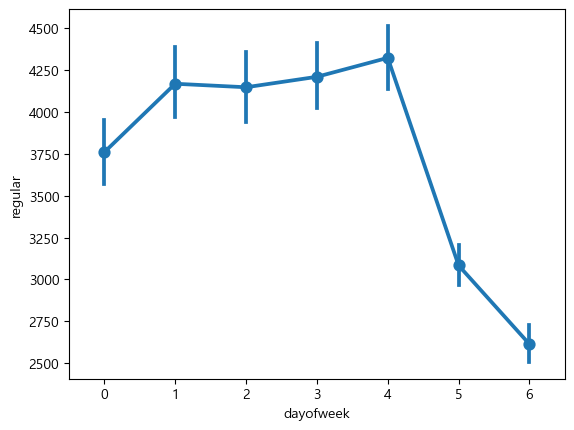

In [55]:
sns.pointplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'regular')

- casual 이용자 (비정기 사용자)

| 요일 | 월\~금   | 토      | 일       |
| -- | ------ | ------ | ------- |
| 패턴 | 평일엔 낮음 | 토요일 최고 | 일요일도 높음 |


- 평일에는 거의 사용하지 않음

- 주말(5, 6)에 이용량이 급증 → 레저/여가 목적일 가능성이 높음

- casual은 주말형 사용자   
→ 토·일 관광지/공원 인근 자전거 공급 강화 필요

<Axes: xlabel='dayofweek', ylabel='casual'>

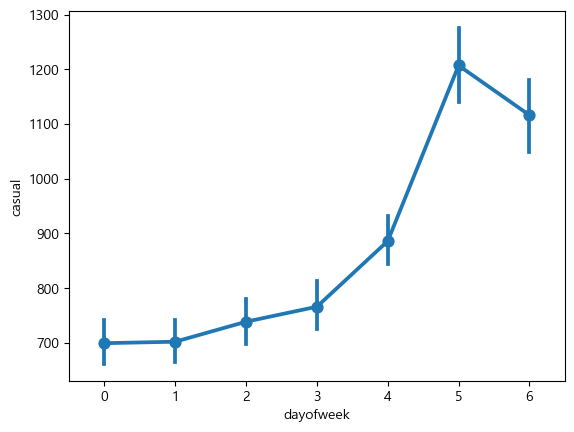

In [56]:
sns.pointplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'casual')

- group 이용자 (단체 대여)

| 요일 | 월\~목 | 금     | 토·일    |
| -- | ---- | ----- | ------ |
| 패턴 | 낮음   | 조금 증가 | 급격히 증가 |

- 주말(토·일)에만 집중적으로 발생

- 평일엔 거의 없음 → 행사나 체험 활동 등 단체 외출에 한정

=> group은 완전히 주말 전용 수요   
→ 단체 예약 대응이나 주말 이벤트 기반 운영 정책 필요

<Axes: xlabel='dayofweek', ylabel='group'>

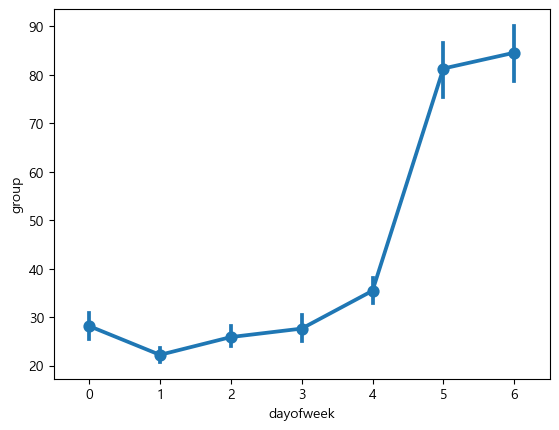

In [57]:
sns.pointplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'group')

| 요일별 패턴    | `regular` | `casual` | `group`    |
| --------- | --------- | -------- | ---------- |
| 평일 (월\~금) | 사용량 높음    | 낮음       | 거의 없음      |
| 주말 (토/일)  | 사용 급감     | **급증**   | **폭발적 증가** |


##  windforce & type
- 바람세기 (0: 바람이 영향을 줄만큼 세지 않음, 1: 영향을 줄만큼 셈)

- regular 사용자

    - 바람이 불든 말든 거의 차이 없음

- windforce=1일 때 소폭 증가했지만 신뢰구간이 겹치므로 유의미한 차이는 아님

➡️ 정기 이용자는 날씨에 크게 구애받지 않음 → 출퇴근 등의 실수요자이기 때문   
→ 운영 측면에서는 예측 가능한 수요군

<Axes: xlabel='windforce', ylabel='regular'>

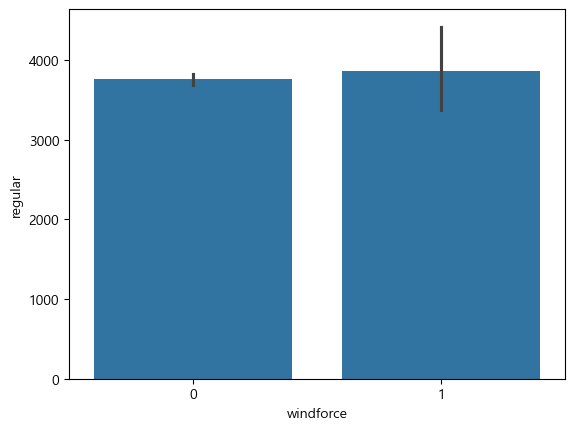

In [59]:
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'regular')

- casual 사용자

    - windforce=1일 때 이용량 증가

에러바(신뢰구간)가 넓어 통계적으로 완전히 확신하긴 어려우나, 경향은 있음

➡️ 의외로 바람이 불어도 casual 사용자는 많이 탐
→ 바람 영향이 아주 크진 않음
(예: 시원한 날씨라면 바람이 오히려 야외 활동에 긍정적으로 작용할 수도 있음)

<Axes: xlabel='windforce', ylabel='casual'>

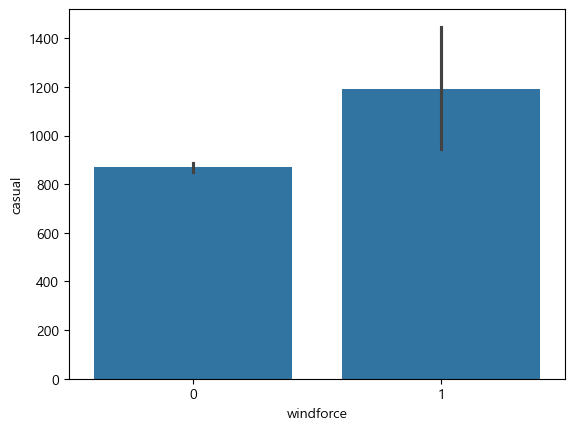

In [60]:
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'casual')

- group 사용자
    - windforce=1일 때 이용량이 훨씬 많아짐

- 다만 신뢰구간이 아주 크므로 표본 수가 적고 변동성이 큼

➡️ 단체 활동은 바람이 불어도 진행되는 경우가 많음, 오히려 일정이 고정된 행사(워크숍, 캠프) 등일 가능성   
→ 바람보다 날짜 고정성이 더 큰 변수

<Axes: xlabel='windforce', ylabel='group'>

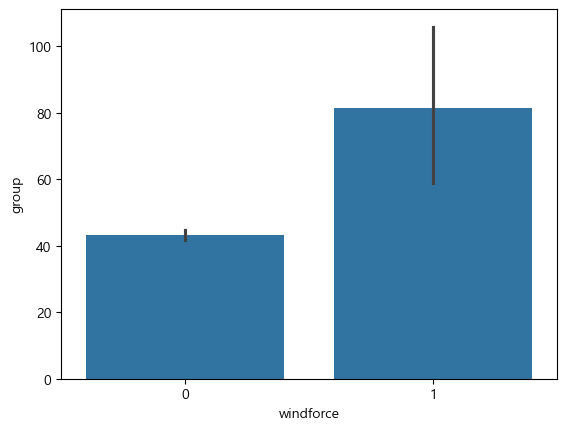

In [61]:
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'group')

| 사용자 유형    | 바람의 영향      | 해석 요약                 |
| --------- | ----------- | --------------------- |
| `regular` | 영향 거의 없음    | 실수요자 (출퇴근 등), 날씨에 둔감  |
| `casual`  | 오히려 약간 증가   | 시원한 바람 선호, 야외활동성 수요   |
| `group`   | 증가하긴 하나 불확실 | 고정 일정 기반의 단체 활동 가능성 큼 |


## discomfort & type
- 불쾌지수

- regular 사용자
    - discomfort 값이 커질수록 대체로 이용량 증가

- 0일 때 가장 낮고, 1~3 구간은 비교적 유지됨
- 단, 3에서 신뢰구간이 넓어져 통계적 확실성은 다소 낮음

➡️ 정기 사용자(출퇴근 등)는 불쾌지수에 크게 영향을 받지 않음   
오히려 무더운 날도 자전거를 활용하는 경향   
→ 아마도 교통비/시간 절약 등 실용적 이유로 탑승 강행하거나 걸어가기 보다는 자전거를 선택하는 것으로 추정

<Axes: xlabel='discomfort', ylabel='regular'>

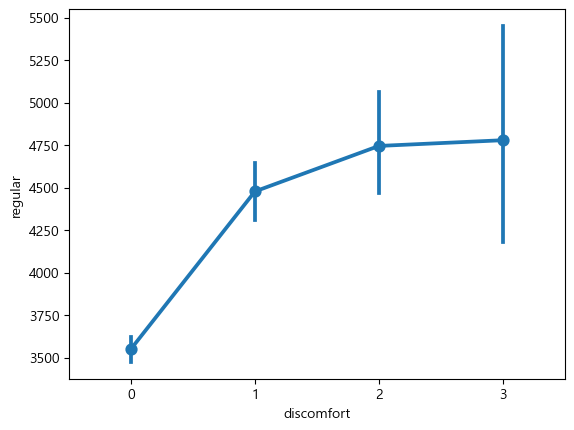

In [65]:
sns.pointplot(data = datetime_rcg_weather, x = 'discomfort', y = 'regular')

- casual 사용자
    - discomfort=0 → 1에서 급증

    - 1~3 구간에서는 다소 평평하거나 소폭 감소

- 전반적으로는 불쾌지수가 너무 낮거나 너무 높아도 사용량 줄어듦

➡️ 쾌적한 날씨(약간 더운 정도)에 가장 많이 탑승   
→ 레저·관광 목적 사용자들은 적당히 더운 날씨 선호,   
너무 시원하거나 너무 덥고 습한 날엔 자제

<Axes: xlabel='discomfort', ylabel='casual'>

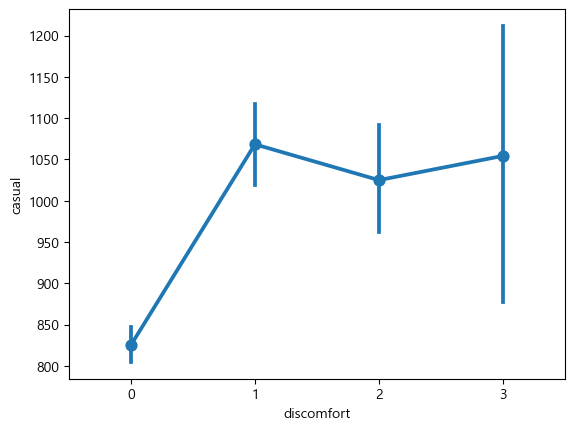

In [63]:
sns.pointplot(data = datetime_rcg_weather, x = 'discomfort', y = 'casual')

- group 사용자
    - 0 → 1에서 증가

    - 1~3 구간은 거의 플랫하지만 불확실성 큼 (신뢰구간 넓음)

➡️ 단체는 불쾌지수와 무관하게 일정 강행   
→ 단체 행사는 정해진 일정대로 진행되는 경향 → 날씨보다 외부 요인이 중요



<Axes: xlabel='discomfort', ylabel='group'>

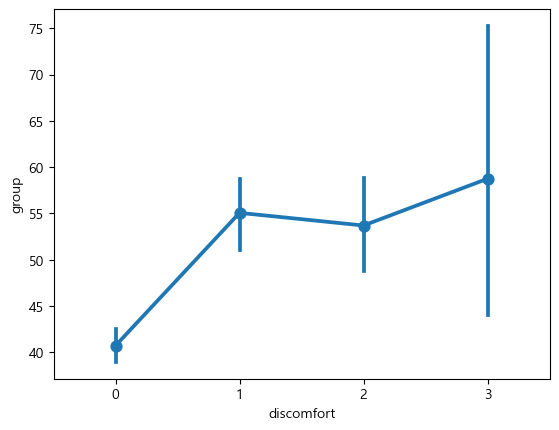

In [64]:
sns.pointplot(data = datetime_rcg_weather, x = 'discomfort', y = 'group')

| 사용자 유형    | 불쾌지수에 따른 변화              | 해석 요약                      |
| --------- | ------------------------ | -------------------------- |
| `regular` | 오히려 다소 증가함               | 출퇴근 수요라 날씨와 무관하게 이용 강행 or 걸어가기보단 자전거를 선택하는 경향 |
| `casual`  | 1단계(약간 불쾌)에서 최대치 | 쾌적한 외출 날씨에 반응          |
| `group`   | 일정한 증가, 불확실성 큼           | 정해진 단체 일정이 더 큰 변수      |


<Axes: xlabel='hour', ylabel='group'>

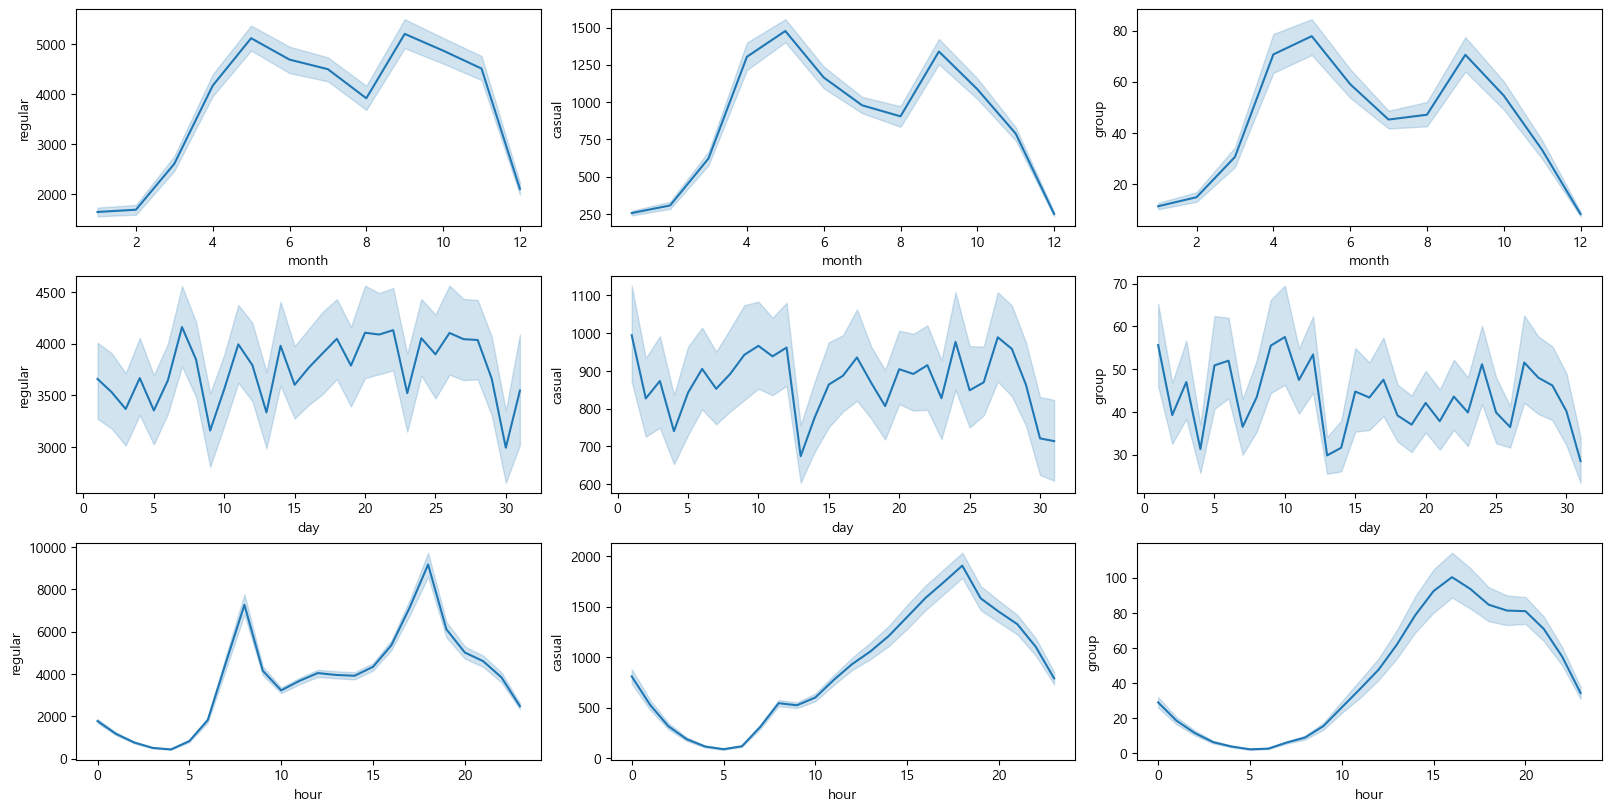

In [68]:
# 그래프를 하나씩 그리다 보면 보기가 까다로우니까 한번에 보기
fig, ((ax1, ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9))= plt.subplots(nrows = 3, ncols = 3,constrained_layout = True)   

fig.set_size_inches(16,8)  
sns.lineplot(data = datetime_rcg_weather, x = 'month', y = 'regular',ax = ax1 )
sns.lineplot(data = datetime_rcg_weather, x = 'month', y = 'casual',ax = ax2 )
sns.lineplot(data = datetime_rcg_weather, x = 'month', y = 'group',ax = ax3 )
sns.lineplot(data = datetime_rcg_weather, x = 'day', y = 'regular',ax = ax4 )
sns.lineplot(data = datetime_rcg_weather, x = 'day', y = 'casual',ax = ax5 )
sns.lineplot(data = datetime_rcg_weather, x = 'day', y = 'group',ax = ax6 )
sns.lineplot(data = datetime_rcg_weather, x = 'hour', y = 'regular',ax = ax7 )
sns.lineplot(data = datetime_rcg_weather, x = 'hour', y = 'casual',ax = ax8 )
sns.lineplot(data = datetime_rcg_weather, x = 'hour', y = 'group',ax = ax9 )

<Axes: xlabel='discomfort', ylabel='group'>

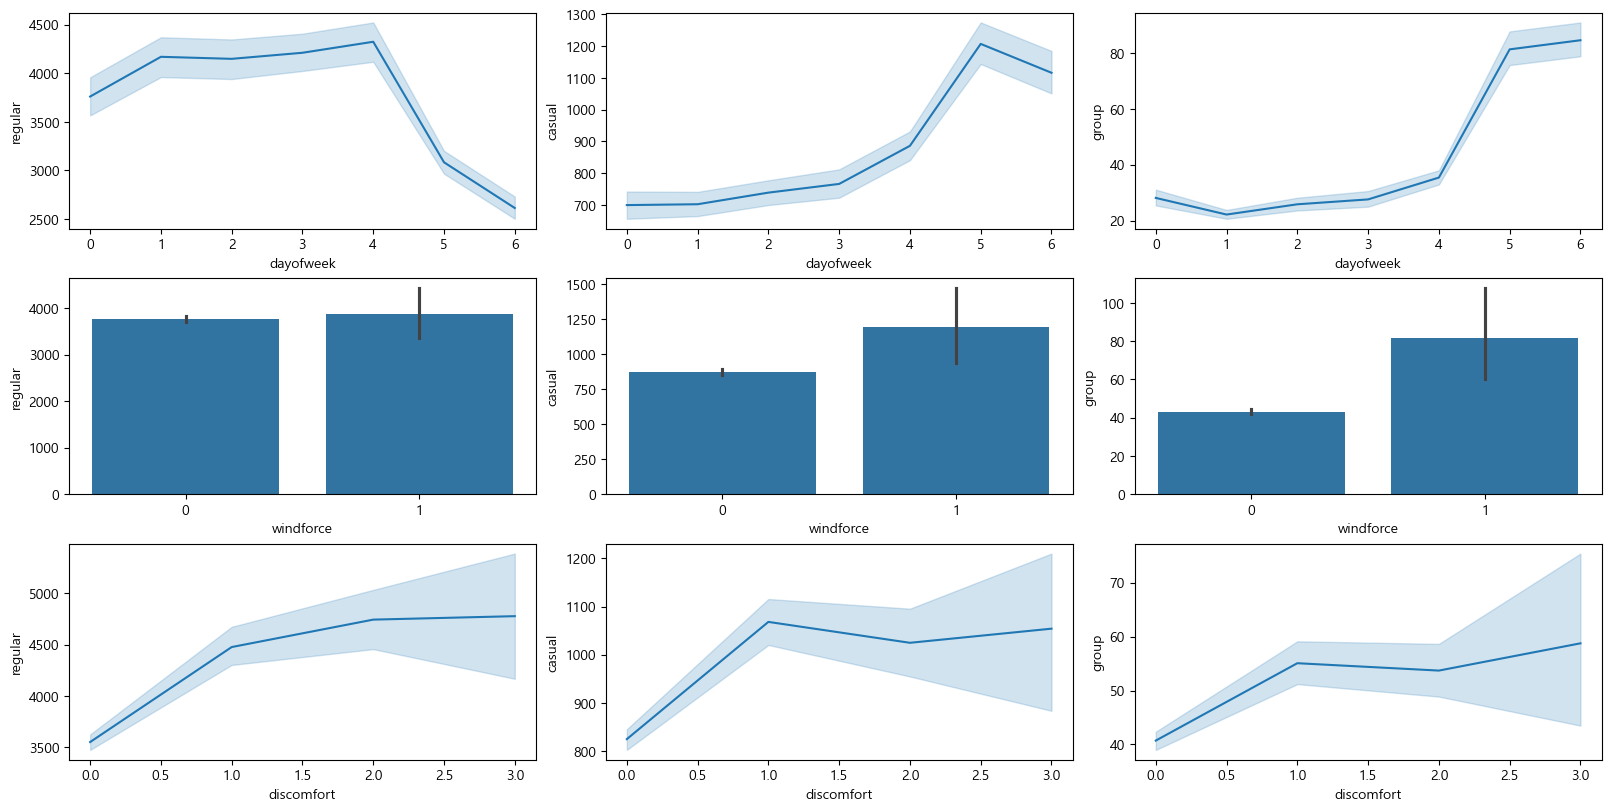

In [69]:
fig,((ax10,ax11,ax12), (ax13,ax14,ax15),(ax16,ax17,ax18))= plt.subplots(nrows = 3, ncols = 3, constrained_layout = True)   
fig.set_size_inches(16,8)
# fig.tight_layout()

sns.lineplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'regular',ax = ax10 )
sns.lineplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'casual',ax = ax11 )
sns.lineplot(data = datetime_rcg_weather, x = 'dayofweek', y = 'group',ax = ax12 )
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'regular',ax = ax13 )
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'casual',ax = ax14 )
sns.barplot(data = datetime_rcg_weather, x = 'windforce', y = 'group',ax = ax15 )
sns.lineplot(data = datetime_rcg_weather, x = 'discomfort', y = 'regular',ax = ax16 )
sns.lineplot(data = datetime_rcg_weather, x = 'discomfort', y = 'casual',ax = ax17 )
sns.lineplot(data = datetime_rcg_weather, x = 'discomfort', y = 'group',ax = ax18 )

## 미세먼지
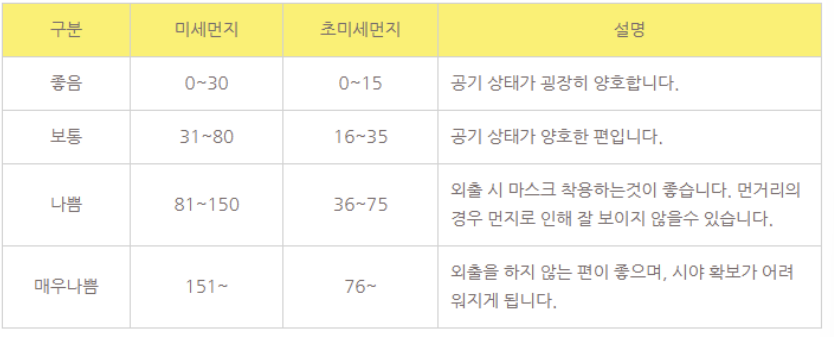

https://blog.naver.com/kopajago/223047035108 
- 좋음, 보통, 나쁨, 매우나쁨으로 구분해서 새로운 칼럼 제작

In [71]:
datetime_rcg_weather['미세먼지(PM10)'].describe()

count    8759.000000
mean       36.647943
std        24.062745
min         3.000000
25%        22.000000
50%        32.000000
75%        45.000000
max       365.000000
Name: 미세먼지(PM10), dtype: float64

In [72]:
# 미세먼지 농도에 따라 구분 기준 
datetime_rcg_weather['PM10 classification'] = 'good'  # 좋음
datetime_rcg_weather.loc[datetime_rcg_weather['미세먼지(PM10)'] > 30, 'PM10 classification'] = 'average'  # 보통
datetime_rcg_weather.loc[datetime_rcg_weather['미세먼지(PM10)'] > 80, 'PM10 classification'] = 'bad'  # 나쁨
datetime_rcg_weather.loc[datetime_rcg_weather['미세먼지(PM10)'] > 150, 'PM10 classification'] = 'very bad'  # 매우 나쁨
datetime_rcg_weather.head()

,datetime,casual,group,regular,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort,year,month,day,hour,dayofweek,PM10 classification
0,2022-01-01 00:00:00,145.0,12.0,418.0,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0,2022,1,1,0,5,good
1,2022-01-01 01:00:00,117.0,1.0,348.0,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0,2022,1,1,1,5,good
2,2022-01-01 02:00:00,57.0,1.0,270.0,-11.0,-17.0,62.0,2.0,25.0,9.0,0,-15.645662,0,2022,1,1,2,5,good
3,2022-01-01 03:00:00,63.0,1.0,186.0,-12.0,-18.0,61.0,2.0,27.0,9.0,0,-16.718002,0,2022,1,1,3,5,good
4,2022-01-01 04:00:00,68.0,8.0,170.0,-13.0,-17.0,72.0,4.0,20.0,7.0,0,-17.645662,0,2022,1,1,4,5,good


In [74]:
datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'very bad'].shape

(36, 19)

In [75]:
print(datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'good'].shape,
datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'average'].shape,
datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'bad'].shape,
datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'very bad'].shape)

(4009, 19) (4401, 19) (313, 19) (36, 19)


In [76]:
datetime_rcg_weather[datetime_rcg_weather['PM10 classification'] == 'bad']

,datetime,casual,group,regular,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort,year,month,day,hour,dayofweek,PM10 classification
113,2022-01-05 17:00:00,471.0,19.0,4334.0,0.0,-12.0,40.0,9.0,88.0,40.0,0,-4.191692,0,2022,1,5,17,2,bad
114,2022-01-05 18:00:00,574.0,18.0,5852.0,-1.0,-12.0,43.0,7.0,81.0,34.0,0,-5.191692,0,2022,1,5,18,2,bad
143,2022-01-06 23:00:00,145.0,1.0,909.0,-7.0,-12.0,68.0,6.0,85.0,47.0,0,-11.191692,0,2022,1,6,23,3,bad
144,2022-01-07 00:00:00,127.0,7.0,605.0,-6.0,-11.0,68.0,9.0,83.0,48.0,0,-10.079420,0,2022,1,7,0,4,bad
145,2022-01-07 01:00:00,85.0,9.0,434.0,-8.0,-12.0,73.0,7.0,90.0,52.0,0,-12.191692,0,2022,1,7,1,4,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,2022-12-21 23:00:00,102.0,2.0,1002.0,-3.0,-7.0,74.0,11.0,84.0,30.0,0,-6.541948,0,2022,12,21,23,2,bad
8519,2022-12-22 00:00:00,150.0,0.0,822.0,-3.0,-8.0,69.0,22.0,92.0,24.0,0,-6.690710,0,2022,12,22,0,3,bad
8520,2022-12-22 01:00:00,151.0,4.0,697.0,-4.0,-9.0,69.0,15.0,92.0,21.0,0,-7.829482,0,2022,12,22,1,3,bad
8521,2022-12-22 02:00:00,85.0,2.0,460.0,-5.0,-10.0,68.0,11.0,83.0,20.0,0,-8.958863,0,2022,12,22,2,3,bad


## 미세먼지 & type

- regular 사용자
    - good ~ average까지는 큰 변화 없음

    - bad일 때 이용량 급감

    - very bad일 때 일부 회복 보이지만 신뢰구간 매우 큼 (불확실성 큼)

➡️ 정기 사용자도 미세먼지가 매우 나쁠 땐 일부 이용 자제   
다만 출퇴근 수요로 인해 완전히 포기되진 않음   
→ 약간의 영향은 있으나 의무적인 이용 성격이 유지됨

<Axes: xlabel='PM10 classification', ylabel='regular'>

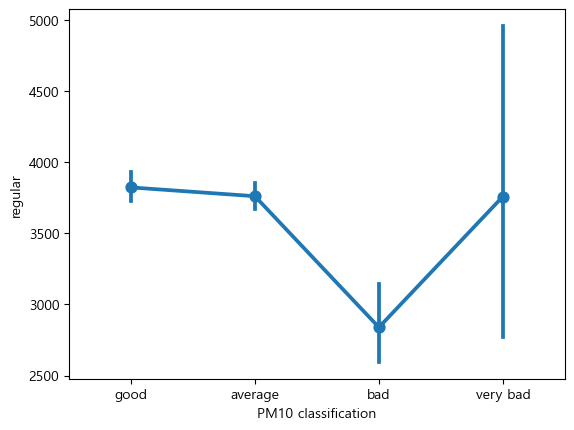

In [77]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM10 classification', y = 'regular')

- casual 사용자
    - good, average에서 거의 동일 → 미세먼지 좋을수록 잘 탐

    - bad에서 급격한 감소, very bad는 더 줄어듦

    - 에러바 크지만 뚜렷한 하락 추세

➡️ casual 사용자는 미세먼지에 민감하게 반응함   
→ 건강이나 체험 목적이라 미세먼지에 민감하게 사용 여부 결정   
공공 자전거 수요 예측에 미세먼지 반영 필요



<Axes: xlabel='PM10 classification', ylabel='casual'>

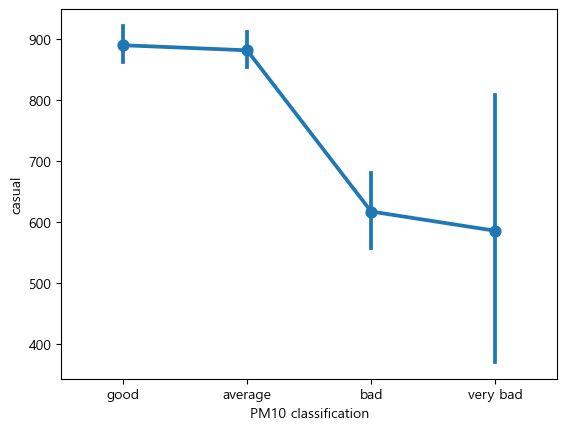

In [78]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM10 classification', y = 'casual')

- group 사용자
    - good, average: 이용량 유지
    - bad, very bad: 뚜렷한 하락
➡️ 단체 활동도 미세먼지에 예민하게 반응   
→ 미세먼지가 일정 기준 이상이면 행사 자체가 취소되는 경우로 추정 가능   
→ 특히 학생/가족 단체 중심이라면 영향 더 큼

<Axes: xlabel='PM10 classification', ylabel='group'>

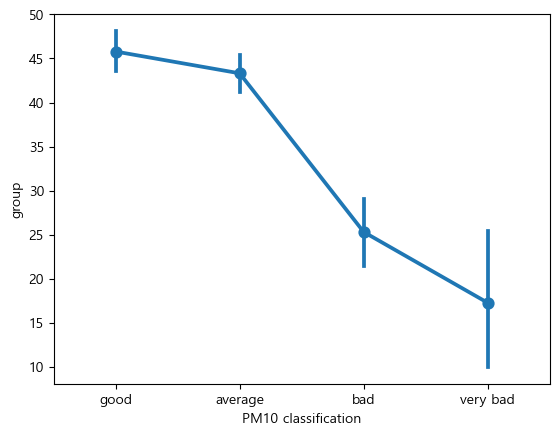

In [79]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM10 classification', y = 'group')

| 사용자       | 미세먼지 영향              | 해석 요약                 |
| --------- | -------------------- | --------------------- |
| `regular` | **약한 영향** (bad부터 감소) | 출퇴근 주 수요, 다소 참고 이용    |
| `casual`  | **강한 영향** (bad부터 급감) | 여가 목적, 날씨/공기질에 민감     |
| `group`   | **명확한 영향**           | 단체 일정이 미세먼지로 취소되거나 변경 |


## 초미세먼지
- https://blog.naver.com/kopajago/223047035108 
- 좋음, 보통, 나쁨, 매우나쁨으로 구분해서 새로운 칼럼 제작

In [80]:
datetime_rcg_weather['초미세먼지(PM2.5)'].describe()

count    8759.000000
mean       18.432226
std        13.632017
min         1.000000
25%         9.000000
50%        15.000000
75%        24.000000
max       104.000000
Name: 초미세먼지(PM2.5), dtype: float64

In [81]:
# 초미세먼지 농도에 따라 구분 기준 
datetime_rcg_weather['PM2.5 classification'] = 'good'  # 좋음
datetime_rcg_weather.loc[datetime_rcg_weather['초미세먼지(PM2.5)'] > 15, 'PM2.5 classification'] = 'average'  # 보통
datetime_rcg_weather.loc[datetime_rcg_weather['초미세먼지(PM2.5)'] > 35, 'PM2.5 classification'] = 'bad'  # 나쁨
datetime_rcg_weather.loc[datetime_rcg_weather['초미세먼지(PM2.5)'] > 75, 'PM2.5 classification'] = 'very bad'  # 매우 나쁨
datetime_rcg_weather.head()

,datetime,casual,group,regular,temp,dew,humid,windspeed,미세먼지(PM10),초미세먼지(PM2.5),windforce,humidex,discomfort,year,month,day,hour,dayofweek,PM10 classification,PM2.5 classification
0,2022-01-01 00:00:00,145.0,12.0,418.0,-9.0,-18.0,48.0,7.0,22.0,7.0,0,-13.718002,0,2022,1,1,0,5,good,good
1,2022-01-01 01:00:00,117.0,1.0,348.0,-11.0,-17.0,62.0,6.0,29.0,10.0,0,-15.645662,0,2022,1,1,1,5,good,good
2,2022-01-01 02:00:00,57.0,1.0,270.0,-11.0,-17.0,62.0,2.0,25.0,9.0,0,-15.645662,0,2022,1,1,2,5,good,good
3,2022-01-01 03:00:00,63.0,1.0,186.0,-12.0,-18.0,61.0,2.0,27.0,9.0,0,-16.718002,0,2022,1,1,3,5,good,good
4,2022-01-01 04:00:00,68.0,8.0,170.0,-13.0,-17.0,72.0,4.0,20.0,7.0,0,-17.645662,0,2022,1,1,4,5,good,good


## 초미세먼지 & type

- regular 사용자
    - good ~ average: 큰 차이 없이 유지
    - bad부터 뚜렷하게 감소, very bad에서 급감
    - 이용량이 절반 이하로 떨어짐

➡️ 초미세먼지(PM2.5)는 regular 사용자에게도 강한 영향   
→ 출퇴근이라도 건강 위해 포기하는 경우 증가   
→ PM10보다 더 민감하게 반응

<Axes: xlabel='PM2.5 classification', ylabel='regular'>

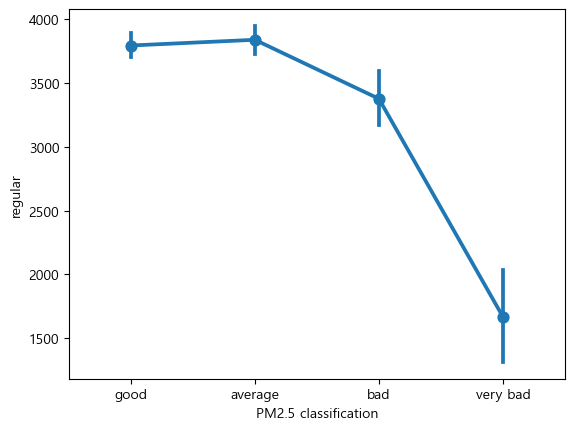

In [86]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM2.5 classification', y = 'regular')

- casual 사용자
    - good~average: 높게 유지

    - bad부터 급격히 감소 → very bad에서 최저치

➡️ casual 사용자는 초미세먼지에 직접적으로 반응   
→ 외출 자체를 자제하거나, 마스크 착용이 부담되어 이용 회피

<Axes: xlabel='PM2.5 classification', ylabel='casual'>

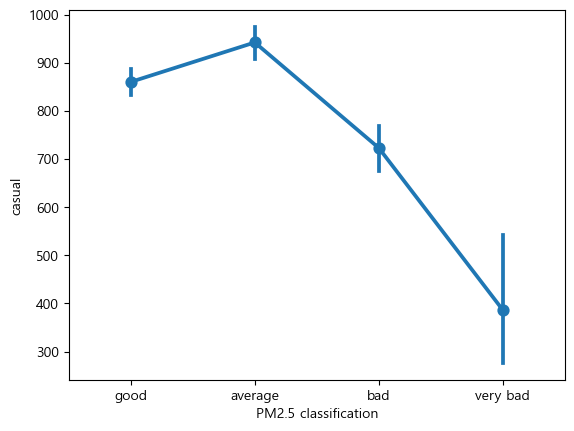

In [85]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM2.5 classification', y = 'casual')

- group 사용자
    - average까지는 유지

    - bad, very bad에서 뚜렷한 감소

    - very bad는 급감, 변동성 있음 (단체 수 적음)

➡️ 단체 행사도 초미세먼지에는 예민하게 반응   
→ 미세먼지가 나쁠 경우, 행사 취소/연기 가능성

<Axes: xlabel='PM2.5 classification', ylabel='group'>

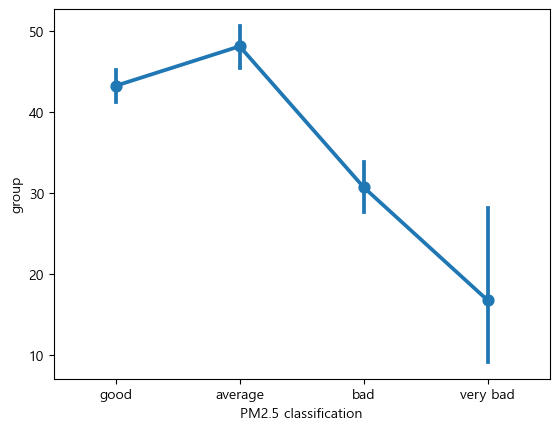

In [84]:
sns.pointplot(data = datetime_rcg_weather, x = 'PM2.5 classification', y = 'group')

| 사용자 유형    | PM2.5 영향 요약              | 해석                       |
| --------- | ------------------------ | ------------------------ |
| `regular` | **명확한 감소** (very bad 급감) | 출퇴근조차 포기할 수준             |
| `casual`  | **뚜렷한 민감성**              | 외출 목적 수요, 건강 우려로 회피      |
| `group`   | **강한 영향**                | 일정 취소 가능성, 야외 단체 행사 영향 큼 |


## 날시 변수와 이용량의 상관관계 분석
-  어떤 기상 요인이 대여량에 영향을 주는지 확인

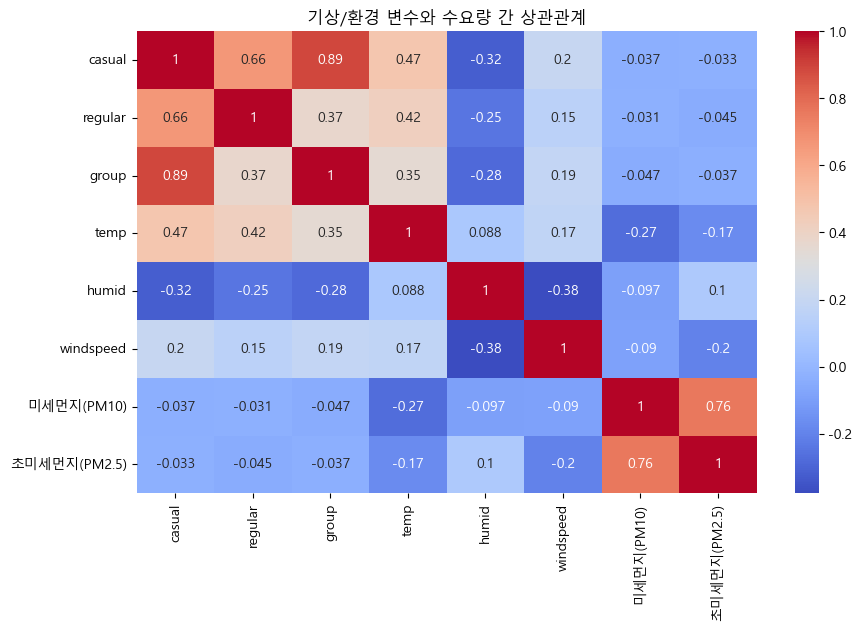

In [93]:
import seaborn as sns
plt.figure(figsize=(10,6))
corr_cols = ['casual', 'regular', 'group', 'temp', 'humid', 'windspeed', '미세먼지(PM10)', '초미세먼지(PM2.5)']
sns.heatmap(datetime_rcg_weather[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('기상/환경 변수와 수요량 간 상관관계')
plt.show()
# 기온 (temp)
# casual: 0.47
# regular: 0.42
# group: 0.35
# ➡️ 기온이 높을수록 수요 증가

# 습도 (humid)
# 전체적으로 음의 상관관계 (ex: casual: -0.32)
# ➡️ 습도가 높을수록 이용량 감소
# → 땀이 나기 쉬운 환경에서는 대여 꺼리는 경향

# 풍속 (windspeed)
# casual: 0.20
# group: 0.19
# regular: 0.15
# ➡️ 상관계수는 낮지만 약한 양의 상관관계
# → 바람이 매우 약한 날보단 적당한 바람 있는 날 야외 활동 증가 가능성 

# 미세먼지 (PM10) / 초미세먼지 (PM2.5)
# 모든 이용자와 음의 상관관계
# 수치상 상관계는 매우 약함
# 실제 EDA(등급별 boxplot 등)에서는 미세먼지 ‘나쁨’ 이상일 때 뚜렷한 수요 감소가 있었음

### 기온 & 이용량

- 기온이 오를수록 이용량이 증가하는 경향이 뚜렷하게 보임.
- 특히 10도 이상~25도 사이에서 사용량이 가파르게 증가.
- 이후에도 증가세는 유지되지만, 30도 이상에선  감소
- 정기적으로 출퇴근하는 사용자층이기 때문에 계절 영향보다는 실용성 중심으로 반응하거나 오히려 적당히 더우면 걷기보다는 자전거를 선택하는 경향이 있음

    - regular 사용자는 기온이 낮으면 자전거를 꺼리지만, 기온이 높아질수록 안정적으로 증가. 하지만 너무 더운 날씨는 이용을 억제할 수 있음.

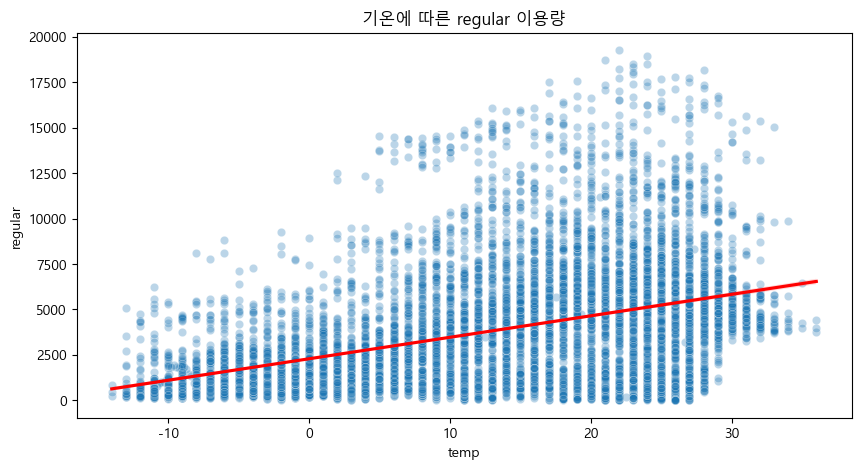

In [97]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=datetime_rcg_weather, x='temp', y='regular', alpha=0.3)
sns.regplot(data=datetime_rcg_weather, x='temp', y='regular', scatter=False, color='red')
plt.title("기온에 따른 regular 이용량")
plt.show()

- 기온이 오를수록 수요가 빠르게 증가.
- 25도 부근에서 최고치에 도달한 뒤 급격히 감소 → 무더운 날씨에 민감하게 반응.
- 점들이 퍼져 있어 편차도 큼: 날씨 외에도 주말/시간/미세먼지 등 복합 요인 영향

    - casual 사용자는 기온이 적당할 때(20~25도)에 자전거를 많이 이용하며, 더위에는 특히 민감하게 반응해 이용량이 급격히 감소. 여가 및 레저 목적의 특성이 반영된 결과라고 해석할 수 있음

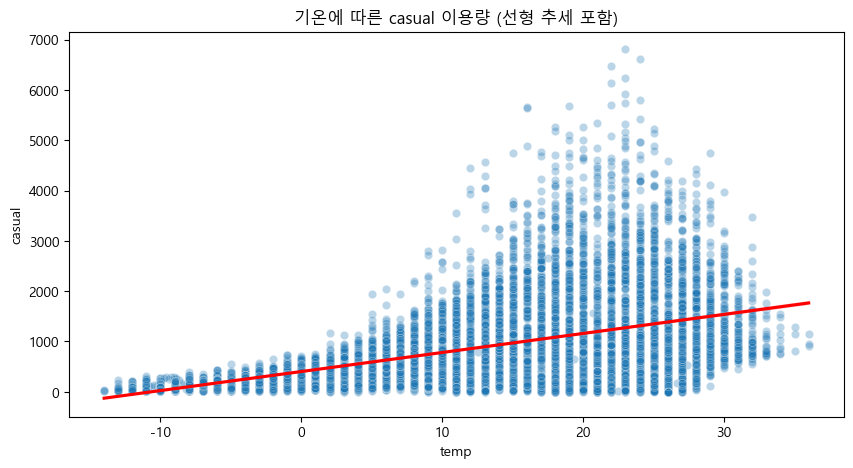

In [96]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=datetime_rcg_weather, x='temp', y='casual', alpha=0.3)
sns.regplot(data=datetime_rcg_weather, x='temp', y='casual', scatter=False, color='red')
plt.title("기온에 따른 casual 이용량")
plt.show()

- casual과 유사한 패턴이지만 스케일은 더 작고 분산도 큼.
- 기온이 올라갈수록 group 수요도 상승하며, 역시 25도 전후에서 정점.
- 이후 이용량은 하락하는 경향.

    - group 이용은 casual과 비슷하게 계절성과 날씨에 민감한 편이며, 적정 온도(약 20~25도)에서 활발히 이용됨.

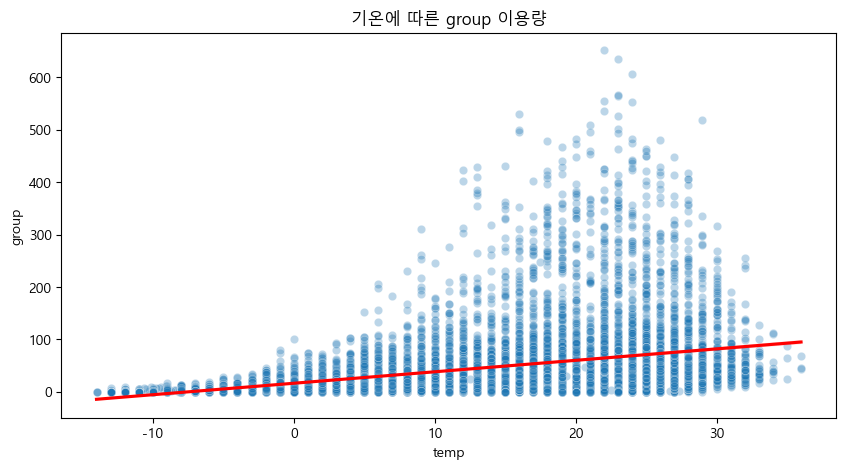

In [99]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=datetime_rcg_weather, x='temp', y='group', alpha=0.3)
sns.regplot(data=datetime_rcg_weather, x='temp', y='group', scatter=False, color='red')
plt.title("기온에 따른 group 이용량")
plt.show()

## 시간대별 이용량 추이 (24시간 × 월별)
- 월별 시간대 이용 패턴이 계절 따라 바뀌는지 시각화

Text(0.5, 1.0, '시간대별 regular 이용량 (월별)')

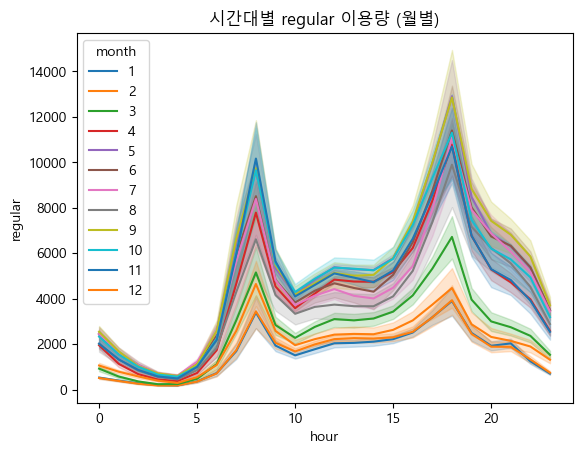

In [89]:
sns.lineplot(data=datetime_rcg_weather, x='hour', y='regular', hue='month', palette='tab10')
plt.title('시간대별 regular 이용량 (월별)')

Text(0.5, 1.0, '시간대별 casual 이용량 (월별)')

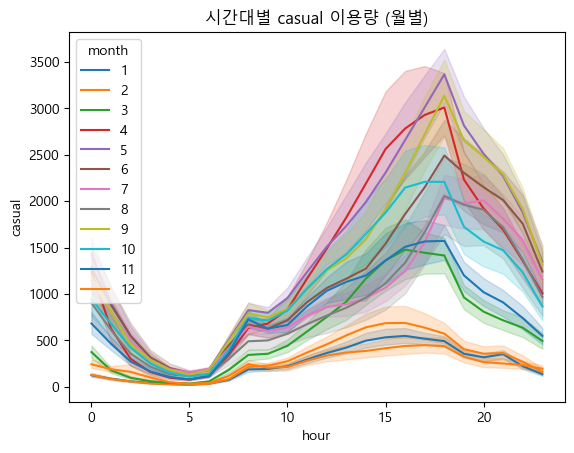

In [116]:
sns.lineplot(data=datetime_rcg_weather, x='hour', y='casual', hue='month', palette='tab10')
plt.title('시간대별 casual 이용량 (월별)')

Text(0.5, 1.0, '시간대별 group 이용량 (월별)')

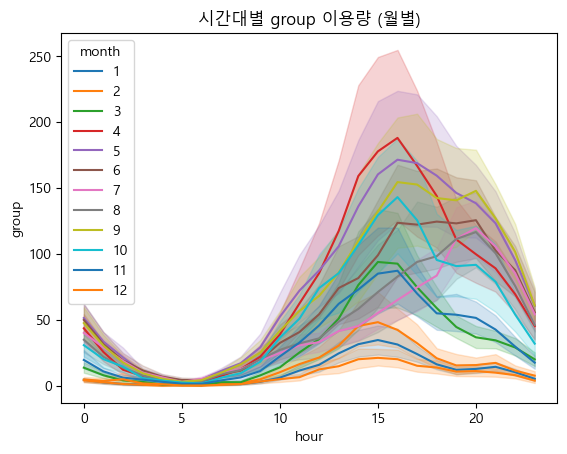

In [117]:
sns.lineplot(data=datetime_rcg_weather, x='hour', y='group', hue='month', palette='tab10')
plt.title('시간대별 group 이용량 (월별)')

## 요일 + 시간대 조합별 히트맵

Text(0.5, 1.0, '요일-시간대별 regular 이용량 히트맵')

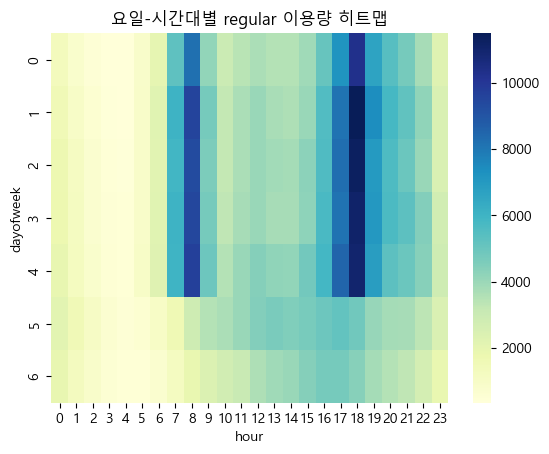

In [109]:
pivot = datetime_rcg_weather.pivot_table(values='regular', index='dayofweek', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('요일-시간대별 regular 이용량 히트맵')

Text(0.5, 1.0, '요일-시간대별 casual 이용량 히트맵')

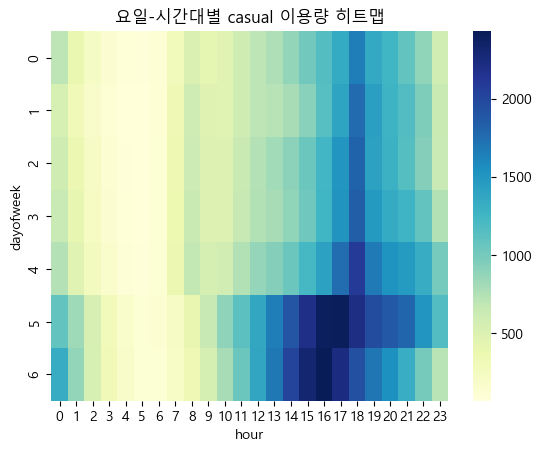

In [113]:
pivot = datetime_rcg_weather.pivot_table(values='casual', index='dayofweek', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('요일-시간대별 casual 이용량 히트맵')

Text(0.5, 1.0, '요일-시간대별 group 이용량 히트맵')

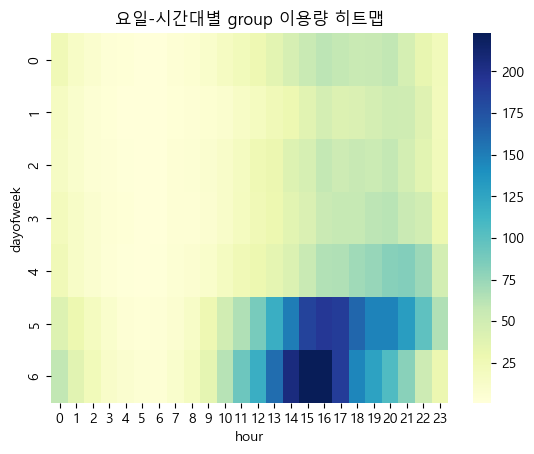

In [114]:
pivot = datetime_rcg_weather.pivot_table(values='group', index='dayofweek', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('요일-시간대별 group 이용량 히트맵')

## gender & type 

In [180]:
df['datetime'] = df['datetime'].astype(str)

df['date_trash'] = df['datetime'].apply(lambda x : x[11:])
df['date_trash'] = df['date_trash'].apply(lambda x : '0' + x)
df['date_trash'] = df['date_trash'].apply(lambda x : x[-8:])
df['day_trash'] = df['datetime'].apply(lambda x : x[:10])

df['datetime'] = df['day_trash'] + ' ' + df['date_trash']
df.drop(['date_trash', 'day_trash'],axis = 'columns', inplace = True)
interested = ['type','gender', 'age', 'datetime']
data2 = df[interested]

In [196]:
data2['count'] = 1
gender_type = data2.groupby(['gender','type']).agg({'count': np.sum})
gender_type.reset_index(inplace = True)

C:\Users\김나현\AppData\Local\Temp\ipykernel_30384\1065140214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['count'] = 1


Text(0.5, 1.0, 'Unidentified type ')

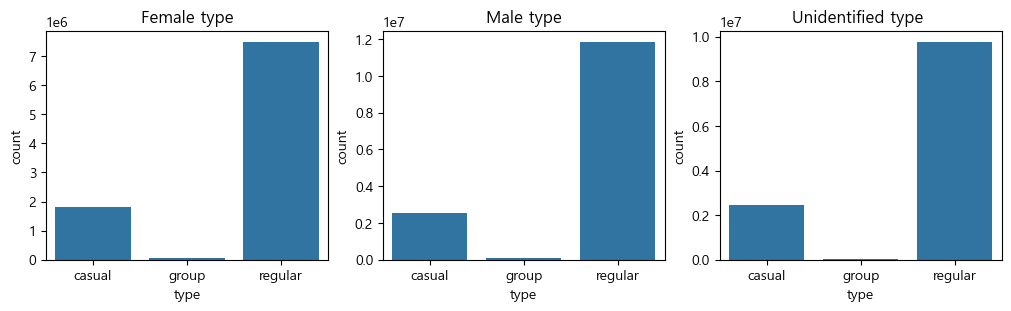

In [197]:
fig,((ax10,ax11,ax12))= plt.subplots(nrows = 1, ncols = 3, constrained_layout = True)   
fig.set_size_inches(10,3)

sns.barplot(data = gender_type[gender_type['gender'] == 'F'], x = 'type', y = 'count',ax = ax10).set_title('Female type')
sns.barplot(data = gender_type[gender_type['gender'] == 'M'], x = 'type', y = 'count', ax = ax11).set_title('Male type')
sns.barplot(data = gender_type[gender_type['gender'] == 'U'], x = 'type', y = 'count', ax = ax12)
plt.title('Unidentified type ')

## type & gender

Text(0.5, 1.0, 'group type ')

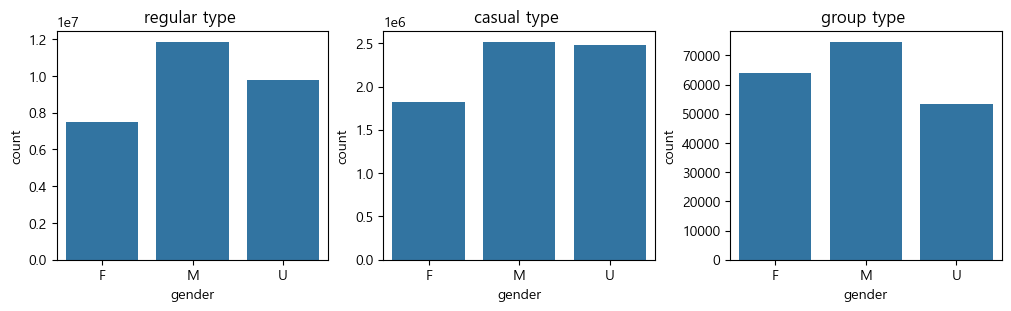

In [198]:
fig,((ax10,ax11,ax12))= plt.subplots(nrows = 1, ncols = 3, constrained_layout = True)   
fig.set_size_inches(10,3)

sns.barplot(data = gender_type[gender_type['type'] == 'regular'], x = 'gender', y = 'count',ax = ax10).set_title('regular type ')
sns.barplot(data = gender_type[gender_type['type'] == 'casual'], x = 'gender', y = 'count', ax = ax11).set_title('casual type ')
sns.barplot(data = gender_type[gender_type['type'] == 'group'], x = 'gender', y = 'count', ax = ax12).set_title('group type ')

## age & type

In [199]:
age_type = data2.groupby(['age','type']).agg({'count': np.sum})
age_type.reset_index(inplace = True)

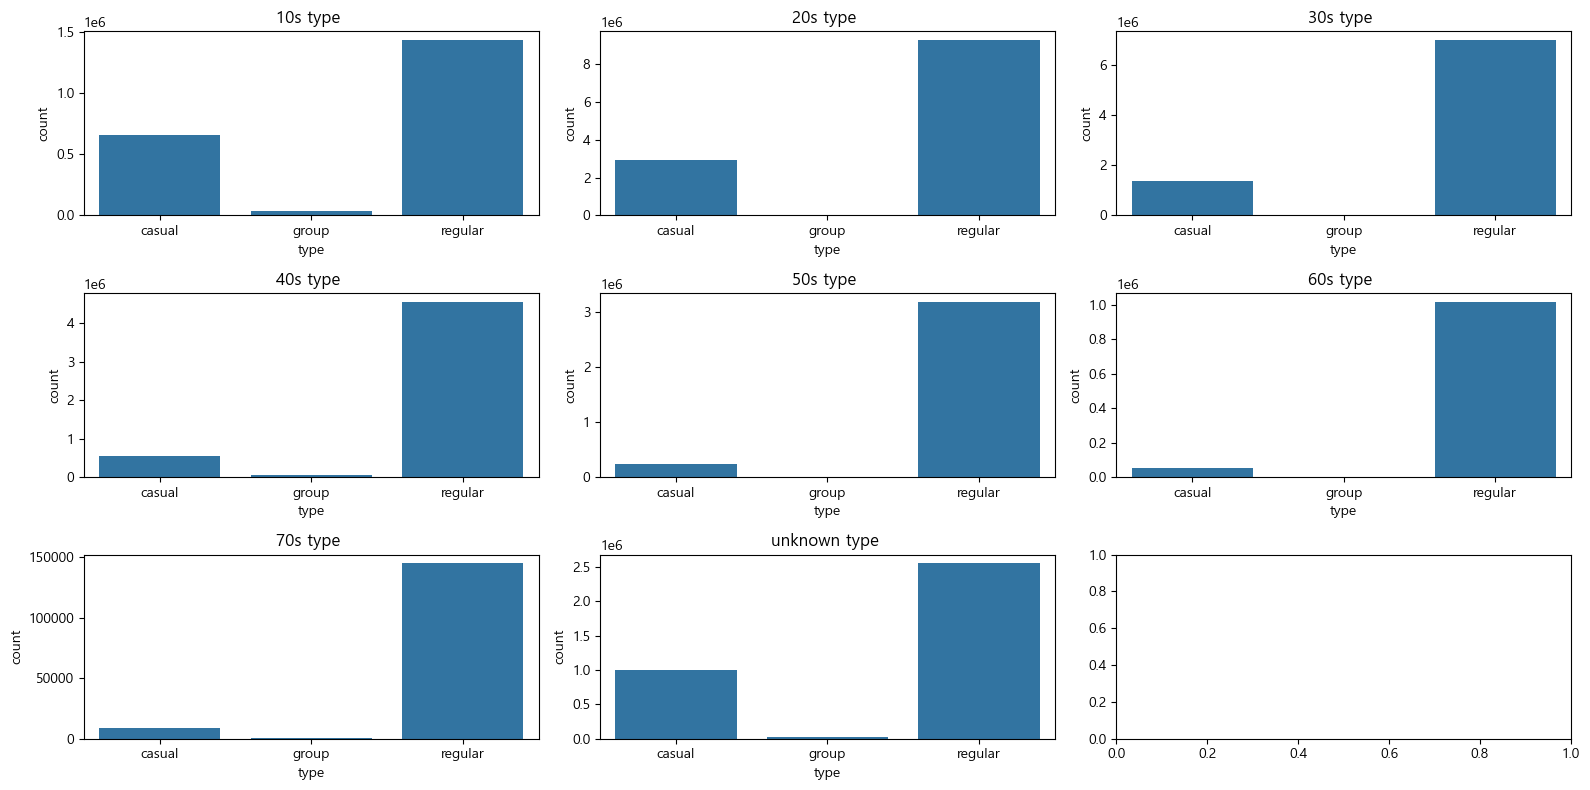

In [202]:
fig,((ax10,ax11,ax12),(ax13,ax14,ax15),(ax16,ax17,ax18))= plt.subplots(nrows = 3, ncols = 3)   
fig.set_size_inches(16,8) 

sns.barplot(data = age_type[age_type['age'] == '10s'], x = 'type', y = 'count',ax = ax10).set_title('10s type ')
sns.barplot(data = age_type[age_type['age'] == '20s'], x = 'type', y = 'count',ax = ax11).set_title('20s type ')
sns.barplot(data = age_type[age_type['age'] == '30s'], x = 'type', y = 'count',ax = ax12).set_title('30s type ')
sns.barplot(data = age_type[age_type['age'] == '40s'], x = 'type', y = 'count',ax = ax13).set_title('40s type ')
sns.barplot(data = age_type[age_type['age'] == '50s'], x = 'type', y = 'count',ax = ax14).set_title('50s type ')
sns.barplot(data = age_type[age_type['age'] == '60s'], x = 'type', y = 'count',ax = ax15).set_title('60s type ')
sns.barplot(data = age_type[age_type['age'] == '70s'], x = 'type', y = 'count',ax = ax16).set_title('70s type ')
sns.barplot(data = age_type[age_type['age'] == 'unknown'], x = 'type', y = 'count',ax = ax17).set_title('unknown type ')
plt.tight_layout()  # 그래프 간격 조정

## type&age

Text(0.5, 1.0, 'group age')

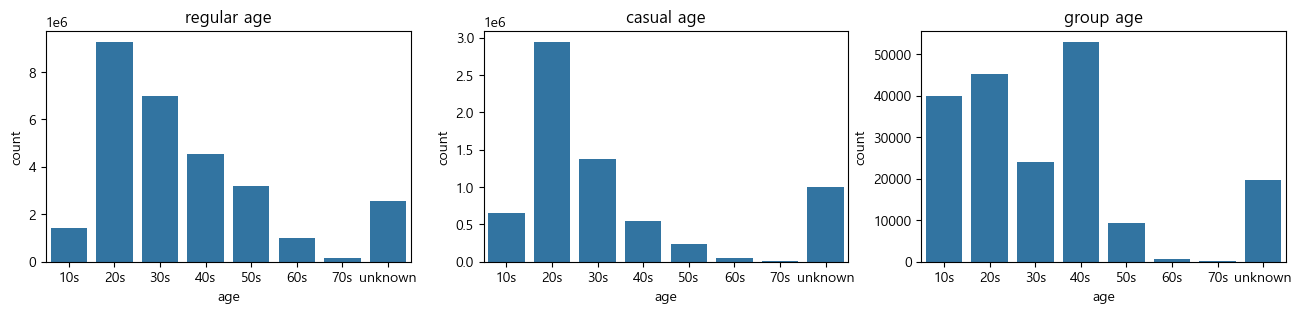

In [201]:
fig,((ax1,ax2,ax3))= plt.subplots(nrows = 1, ncols = 3)   
fig.set_size_inches(16,3)

sns.barplot(data = age_type[age_type['type'] == 'regular'], x = 'age', y = 'count',ax = ax1).set_title('regular age')
sns.barplot(data = age_type[age_type['type'] == 'casual'], x = 'age', y = 'count',ax = ax2).set_title('casual age')
sns.barplot(data = age_type[age_type['type'] == 'group'], x = 'age', y = 'count',ax = ax3).set_title('group age')

# Folium 지도 Heatmap

In [203]:
import folium
from folium.plugins import HeatMap

# 강서구 기준 대여소들 특정 시간대 (2022-06-01 08:00:00) 반납-대여량 시각화
station_sum = eda.groupby(['station_id'])['반납-대여'].sum().reset_index()
bike_num = pd.read_csv('data/대여소위치.tsv', sep='\t', encoding='cp949')
gps = bike_num[['stationIndex', 'lat', 'lon']].rename(columns={'stationIndex':'station_id'})
station_sum['station_id'] = station_sum['station_id'].astype(str)
gps['station_id'] = gps['station_id'].astype(str)

target_time = pd.to_datetime("2022-06-01 08:00:00")
snapshot = eda[eda['datetime'] == target_time].copy()
snapshot['station_id'] = snapshot['station_id'].astype(str)

map_df = snapshot.merge(gps, on='station_id')

m = folium.Map(location=[map_df.lat.mean(), map_df.lon.mean()], zoom_start=12)

for _, r in map_df.iterrows():
    value = r['반납-대여']
    if value > 0:
        color = 'blue'
    elif value < 0:
        color = 'red'
    else:
        color = 'gray'
        
    if abs(value) > 0:
        radius = 5*abs(value)
    else:
        radius = 10
    
    folium.CircleMarker(
        location=[r.lat, r.lon],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"ID:{r.station_id} / 반납-대여:{int(value)}"
    ).add_to(m)

m.save("seoulbike_station_usage.html")

m
